# Atelier Trading 2

Au programme :
- Comment implémenter une stratégie de trading ?
- Comment la "backtester" ?
- Comment optimiser certains de ses paramètres ?

Normalement tout est déjà installé grâce à Google Colab, ou alors sur VS Code vous devez ajouter le dossier Data et requirement.txt dans le même dossier que ce notebook.

Pour simplifier quelques fichiers avec des données rudimentaires de prix et de volume sont déjà accessibles dans le dossier Data.

La stratégie pourra être étendue à d'autres données simplement avec yfinance.
(Petit problème, on est rapidement limité par le nombre de données téléchargeables par requête et sur le nombre de requêtes.
Par exemple, on ne peut pas télécharger plus de 60 jours de données de timeframe 15 minutes.)

Alternatives pour avoir des données un peu plus fournies gratuitement:
- Télécharger manuellement des données sur [Dukascopy](https://www.dukascopy.com/trading-tools/widgets/quotes/historical_data_feed)
- Créer un Paper Trading Account chez Interactive Broker et utiliser leur API, plus compliqué mais permet
d'automatiser un téléchargement de données plus fourni
- Pleins d'autres possibilités (abonnements payants ou gratuits à certains "Datafeed")

Voici le plan que nous allons suivre pour construire notre stratégie :
- Téléchargement des données temporelles de prix
- Traitement des données et ajout d'indicateurs
- Définition des signaux et ajout des signaux pour exécuter un ordre
- Implémentation de la stratégie en elle-même
- Backtesting
- Optimisation des paramètres

In [ ]:
### Installation des packages nécessaires ###
!pip install pandas pandas-ta numpy plotly backtesting==0.3.3 matplotlib==3.3.4 seaborn==0.11.1 yfinance



# Téléchargement des données (comme pour le premier atelier)



In [ ]:
import yfinance as yf
import pandas as pd


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:


def download_data_yfinance():
    ticker_symbol = input("Enter the ticker symbol: ")
    timeframe = input("Enter the timeframe: ")
    start_date = input("Enter the start date (YYYY-MM-DD): ")
    end_date = input("Enter the end date (YYYY-MM-DD): ")

    ticker = yf.Ticker(ticker_symbol)

    df = ticker.history(start=start_date, end=end_date, interval=timeframe)
    df.drop(columns=["Dividends", "Stock Splits"], inplace=True)
    df.index = df.index.tz_convert('Europe/Paris')
    df.to_csv(f"Data/{ticker_symbol.upper()}_{timeframe.upper()}_{start_date}_{end_date}.csv")

    print("Data downloaded successfully in Data folder.")

download_data_yfinance()

# exemple de ticker symbol : AAPL, MSFT, NVDA, TSLA, AMZN, GOOGL, FB ...
# exemple de timeframe : 1m, 5m , 15m, 30m, 1h, 1d
# exemple de start_date et end_date : 2025-02-01
# le fichier sera enregistré dans le dossier Data

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/julienwax/Trading-workshops/main/trading-workshop2/Data/MSFT_15M_2025-02-01_2025-02-10.csv")
pd.set_option('display.max_columns', None)
print(df.info())
print(df.head())
print(len(df))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  130 non-null    object 
 1   Open      130 non-null    float64
 2   High      130 non-null    float64
 3   Low       130 non-null    float64
 4   Close     130 non-null    float64
 5   Volume    130 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 6.2+ KB
None
                    Datetime        Open        High         Low       Close  \
0  2025-02-03 15:30:00+01:00  411.760010  414.720001  409.119995  412.750000   
1  2025-02-03 15:45:00+01:00  412.859985  412.859985  411.250092  411.369995   
2  2025-02-03 16:00:00+01:00  411.250000  411.420013  409.130005  409.250000   
3  2025-02-03 16:15:00+01:00  409.220001  411.970001  408.670013  411.674988   
4  2025-02-03 16:30:00+01:00  411.649994  413.299988  411.109985  413.200012   

    Volume  
0  3731594  
1  1046842

On obtient un fichier avec "datetime" en tant que première colonne et OHLC (Open - High - Low - Close) des prix
pour les 4 prochaines colonnes et enfin la dernière colonne représente le Volume (Nombre de contrats écoulés lors du timeframe
entre 2 datetimes)

# Première implémentation d'une stratégie

## Stratégie numéro 1 : Scalping Bollinger Strategy (Timeframe: 5 minutes)

### Comment fonctionne la stratégie ?

- **Plusieurs indicateurs :**  
    - **EMA** : Deux moyennes mobiles exponentielles pour générer un signal (une sur 30 périodes, l'autre sur 50).  
    - **ATR** : Une moyenne de la taille des bougies pour calculer le stop loss et take profit.  
    - **Bandes de Bollinger** : Utilisées pour la création du deuxième signal (sur 15 bougies).  

- **Signaux :**  
    - On ajoute `0` dans le DataFrame quand il n'y a pas de signal, `1` pour un signal de vente, et `2` pour un signal d'achat.  
    - Si sur une période de 7 bougies :  
    \begin{equation}
       EMA_{fast} < EMA_{slow}
    \end{equation}
      alors on ajoute `1` dans le DataFrame (baissier).  
      Si sur 7 bougies :  
      $$ EMA_{fast} > EMA_{slow} $$  
      alors on ajoute `2` (haussier).  
      Sinon, on ajoute `0`.  
    - Si l'écart par rapport à la moyenne mobile simple (SMA) sur 15 périodes est supérieur à $ 1.5\sigma$ , un signal est généré en considérant le prix élastique.  
    - Le signal total pour exécuter les ordres est **l'intersection des deux premiers**.  

- **Trade management :**  
    - Un seul trade à la fois (on s'assure que la position précédente est fermée avant d'en ouvrir une autre).  
    - Un stop loss et un take profit sont définis dès l'ouverture d'une position, en fonction des paramètres :  
      - $ TPSL$  
      - $ SL_{coef}$  

In [ ]:
### Importation des librairies ###
import pandas as pd
import pandas_ta as ta
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import datetime
from backtesting import Strategy, Backtest
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
### Importation des données et ajout d'indicateur/ trie des données ###
df = pd.read_csv("https://raw.githubusercontent.com/julienwax/Trading-workshops/main/trading-workshop2/Data/META_5M_2025-01-01_2025-02-10.csv")

df=df[df['Volume']!=0]  # On enlève les lignes avec un volume à 0
df.reset_index(drop=True,inplace=True)
df["EMA_slow"]=ta.ema(df.Close, length=50) # Moyenne mobile exponentielle sur 50 périodes
df["EMA_fast"]=ta.ema(df.Close, length=30) # Moyenne mobile exponentielle sur 30 périodes
df['RSI']=ta.rsi(df.Close, length=10)      # Indicateur RSI sur 10 périodes
my_bbands = ta.bbands(df.Close, length=15, std=1.5)   # Bandes de Bollinger
df['ATR']=ta.atr(df.High, df.Low, df.Close, length=7) # Moyenne True Range sur 7 périodes
df = df.join(my_bbands, how='left')                     # On ajoute les bandes de Bollinger au dataframe
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.head())


                    Datetime        Open        High         Low       Close  \
0  2025-01-02 19:35:00+01:00  590.599976  592.190002  590.109985  591.489990   
1  2025-01-02 19:40:00+01:00  591.549988  593.229980  590.964111  593.229980   
2  2025-01-02 19:45:00+01:00  593.000000  593.593994  592.030029  592.409973   
3  2025-01-02 19:50:00+01:00  592.710022  592.760010  591.289978  591.525024   
4  2025-01-02 19:55:00+01:00  591.599976  593.659973  591.599976  593.659973   

   Volume    EMA_slow    EMA_fast        RSI       ATR  BBL_15_1.5  \
0   56130  596.386158  594.167291  43.065778  2.107654  589.494865   
1   62108  596.262387  594.106820  50.509582  2.130266  589.711488   
2   82290  596.111312  593.997346  47.273164  2.049335  589.866135   
3   50060  595.931457  593.837841  43.900175  1.966550  589.850214   
4   65810  595.842380  593.826366  52.907204  1.990614  589.820012   

   BBM_15_1.5  BBU_15_1.5  BBB_15_1.5  BBP_15_1.5  
0  591.674748  593.854630    0.736852    0.457

In [ ]:
# Définition des signaux d'achat et de vente

### EMA Signal (Exponential Moving Average) ###

def ema_signal(df, current_candle, backcandles):
    start = max(0, current_candle - backcandles)
    end = current_candle
    relevant_rows = df.iloc[start:end]
    if all(relevant_rows["EMA_fast"] < relevant_rows["EMA_slow"]):
        return 1                        # Signal de vente (1 pour vente, 2 pour achat)
    elif all(relevant_rows["EMA_fast"] > relevant_rows["EMA_slow"]):
        return 2
    else:
        return 0

def total_signal(df, current_candle, backcandles):
    if (ema_signal(df, current_candle, backcandles)==2
        and df.Close[current_candle]<=df['BBL_15_1.5'][current_candle]
        #and df.RSI[current_candle]<60
        ):
            return 2
    if (ema_signal(df, current_candle, backcandles)==1
        and df.Close[current_candle]>=df['BBU_15_1.5'][current_candle]
        #and df.RSI[current_candle]>40
        ):

            return 1
    return 0

def pointpos(x):        # Pour affichage du backtest
    if x['TotalSignal']==1:
        return x['High']*1.01
    elif x['TotalSignal']==2:
        return x['Low']*0.99
    else:
        return 0

def SIGNAL():
    return df['TotalSignal']

# Ajout des signaux au dataframe

df['EMASignal'] = df.apply(lambda row: ema_signal(df, row.name, 7) , axis=1)
df['TotalSignal'] = df.apply(lambda row: total_signal(df, row.name, 7), axis=1)
df['pointpos'] = df.apply(pointpos, axis=1)

print(df.head())

                    Datetime        Open        High         Low       Close  \
0  2025-01-02 19:35:00+01:00  590.599976  592.190002  590.109985  591.489990   
1  2025-01-02 19:40:00+01:00  591.549988  593.229980  590.964111  593.229980   
2  2025-01-02 19:45:00+01:00  593.000000  593.593994  592.030029  592.409973   
3  2025-01-02 19:50:00+01:00  592.710022  592.760010  591.289978  591.525024   
4  2025-01-02 19:55:00+01:00  591.599976  593.659973  591.599976  593.659973   

   Volume    EMA_slow    EMA_fast        RSI       ATR  BBL_15_1.5  \
0   56130  596.386158  594.167291  43.065778  2.107654  589.494865   
1   62108  596.262387  594.106820  50.509582  2.130266  589.711488   
2   82290  596.111312  593.997346  47.273164  2.049335  589.866135   
3   50060  595.931457  593.837841  43.900175  1.966550  589.850214   
4   65810  595.842380  593.826366  52.907204  1.990614  589.820012   

   BBM_15_1.5  BBU_15_1.5  BBB_15_1.5  BBP_15_1.5  EMASignal  TotalSignal  \
0  591.674748  593.85

In [ ]:
### Definition de la stratégie ###

class ScalpingBollinger_5min(Strategy):
    initsize = 1
    mysize = initsize
    slcoef = 2.1
    TPSLRatio = 2.5
    def init(self):
        super().init()
        self.signal1 = self.I(SIGNAL)
        #df['RSI']=ta.rsi(df.Close, length=self.rsi_length)

    def next(self):
        super().next()
        slatr = self.slcoef*self.data.ATR[-1]
        TPSLRatio = self.TPSLRatio

        # if len(self.trades)>0:                Fermetures des trades si le marché est en surachat ou survente
        #     if self.trades[-1].is_long and self.data.RSI[-1]>=90:
        #         self.trades[-1].close()
        #     elif self.trades[-1].is_short and self.data.RSI[-1]<=10:
        #         self.trades[-1].close()

        if self.signal1==2 and len(self.trades)==0:
            sl1 = self.data.Close[-1] - slatr
            tp1 = self.data.Close[-1] + slatr*TPSLRatio
            self.buy(sl=sl1, tp=tp1, size=self.mysize)

        elif self.signal1==1 and len(self.trades)==0:
            sl1 = self.data.Close[-1] + slatr
            tp1 = self.data.Close[-1] - slatr*TPSLRatio
            self.sell(sl=sl1, tp=tp1, size=self.mysize)

# Backtesting

In [ ]:

def plot_signals(df):
    fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close']),

                go.Scatter(x=df.index, y=df['BBL_15_1.5'],
                           line=dict(color='green', width=1),
                           name="BBL"),
                go.Scatter(x=df.index, y=df['BBU_15_1.5'],
                           line=dict(color='green', width=1),
                           name="BBU"),
                go.Scatter(x=df.index, y=df['EMA_fast'],
                           line=dict(color='black', width=1),
                           name="EMA_fast"),
                go.Scatter(x=df.index, y=df['EMA_slow'],
                           line=dict(color='blue', width=1),
                           name="EMA_slow")])
    df_filtered = df[df["pointpos"]!=0]
    fig.add_scatter(x=df_filtered.index, y=df_filtered["pointpos"], mode="markers",
                marker=dict(size=5, color="MediumPurple"),
                name="entry")
    fig.show()

def SIGNAL():
    return df['TotalSignal']

def run_strategy(df,strategy,cash=100,margin=1/50,commission=.00):
    bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
    stat = bt.run()
    print(stat)
    fig = bt.plot()


In [ ]:
plot_signals(df)

In [ ]:
run_strategy(df,ScalpingBollinger_5min, cash=100, margin=1/10, commission=.00)

<ipython-input-30-a25593ae9c0f>:31: UserWarning:

Some prices are larger than initial cash value. Note that fractional trading is not supported. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (GH-134).

<ipython-input-30-a25593ae9c0f>:31: UserWarning:

Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.



Start                                     0.0
End                                    1899.0
Duration                               1899.0
Exposure Time [%]                   78.736842
Equity Final [$]                   172.727368
Equity Peak [$]                    180.949295
Return [%]                          72.727368
Buy & Hold Return [%]                20.75606
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]                     NaN
Sharpe Ratio                              NaN
Sortino Ratio                             NaN
Calmar Ratio                              0.0
Max. Drawdown [%]                  -32.546226
Avg. Drawdown [%]                   -4.669854
Max. Drawdown Duration                  534.0
Avg. Drawdown Duration              46.394737
# Trades                                 42.0
Win Rate [%]                        33.333333
Best Trade [%]                       4.205598
Worst Trade [%]                     -1.752018
Avg. Trade [%]                    

# Optimisation des paramètres de la stratégie

<ipython-input-11-71f9cbe026e7>:2: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (GH-134).
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
<ipython-input-11-71f9cbe026e7>:2: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
/usr/local/lib/python3.11/dist-packages/backtesting/backtesting.py:1488: UserWarning: Searching for best of 441 configurations.
  output = _optimize_grid()


Backtest.optimize:   0%|          | 0/3 [00:00<?, ?it/s]

Start                                     0.0
End                                    1899.0
Duration                               1899.0
Exposure Time [%]                   80.157895
Equity Final [$]                   219.513275
Equity Peak [$]                    221.513275
Return [%]                         119.513275
Buy & Hold Return [%]                20.75606
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]                     NaN
Sharpe Ratio                              NaN
Sortino Ratio                             NaN
Calmar Ratio                              0.0
Max. Drawdown [%]                  -21.376597
Avg. Drawdown [%]                   -3.758399
Max. Drawdown Duration                  269.0
Avg. Drawdown Duration               31.37037
# Trades                                 42.0
Win Rate [%]                        35.714286
Best Trade [%]                       4.325758
Worst Trade [%]                     -2.940774
Avg. Trade [%]                    

<ipython-input-11-71f9cbe026e7>:10: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("optimization.png")
<ipython-input-11-71f9cbe026e7>:10: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("optimization.png")
<ipython-input-11-71f9cbe026e7>:10: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("optimization.png")
<ipython-input-11-71f9cbe026e7>:10: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("optimization.png")
<ipython-input-11-71f9cbe026e7>:

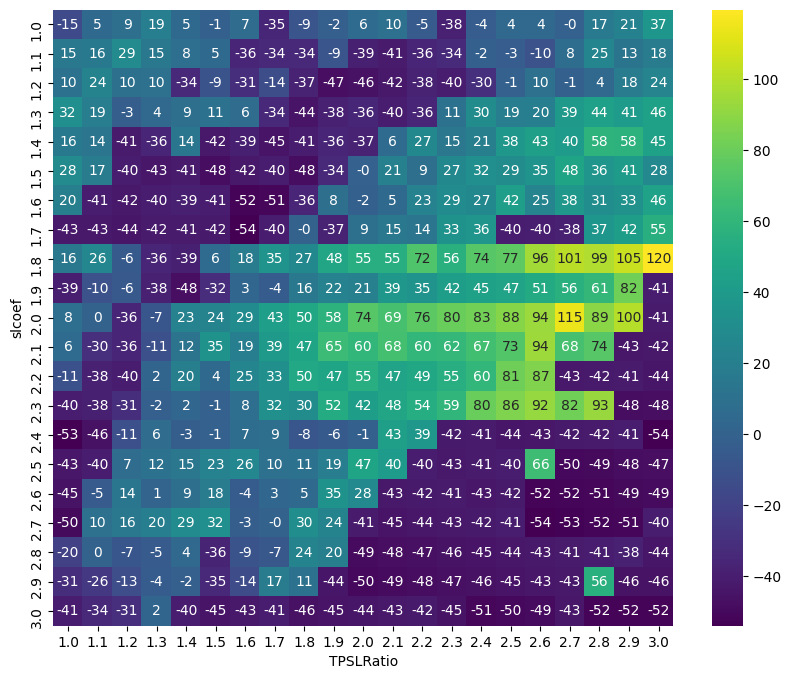

In [ ]:
def optimize_strategy(df,strategy, cash=100, margin=1/10, commission=.00):
    bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
    stats,heatmap = bt.optimize(slcoef = [i/10 for i in range(10, 31)], TPSLRatio = [i/10 for i in range(10, 31)],
    maximize = 'Return [%]', max_tries = 500,random_state = 0, return_heatmap=True)
    print(stats)
    print(stats["_strategy"])
    heatmap_df = heatmap.unstack()
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_df, cmap='viridis', annot=True, fmt=".0f")
    plt.savefig("optimization.png")
    plt.show()

optimize_strategy(df,ScalpingBollinger_5min, cash=100, margin=1/10, commission=.00)

# A vous de contruire votre stratégie !

In [ ]:
### IMPORTEZ VOS DONNEES ###
# Choisissez celles que vous souhaitez
#df = pd.read_csv("https://raw.githubusercontent.com/julienwax/Trading-workshops/main/trading-workshop2/Data/AAPL_5M_2025-01-01_2025-02-15.csv")  # Apple
#df = pd.read_csv("https://raw.githubusercontent.com/julienwax/Trading-workshops/main/trading-workshop2/Data/NVDA_5M_2025-01-01_2025-02-15.csv")  # Nvidia
#df = pd.read_csv("https://raw.githubusercontent.com/julienwax/Trading-workshops/main/trading-workshop2/Data/META_5M_2025-01-01_2025-02-10.csv")  # Meta

# Vous avez les données de AAPL, MSFT, NVDA, META déjà téléchargées dans le dossier Data mais vous pouvez en
# télécharger d'autres avec la fonction download_data_yfinance() (je vous conseille en timeframe 5m) (il y a des fois des bugs avec le nombre de requêtes)

Dans la stratégie précédente, on a utilisé deux paramètres pour gérer nos trades:
- $TPSL$ (Take Profit to Stop Loss ratio) définie par $$ TPSL = \frac{TP_{distance}}{SL_{distance}} $$ où $TP_{distance}$ désigne l'écart de prix entre le prix actuel et le take profit du trade que l'on lance, idem pour $SL_{distance}$ avec le stop loss.

- $SL_{coef}$, en général j'ajoute l'indicateur ATR (Average True Range), c'est la moyenne de la taille des bougies précédentes dans mes données. Le coef précédent permet de calculer notre stop loss selon la formule (pour un LONG):
$$ SL = prix - SL_{coef}*ATR_{actuel}~~et~~TP = prix + SL_{coef}*ATR_{actuel}*TPSL$$

Cette approche permet de grandement simplifier la situation, on a juste à se poser la question quand est-ce que je rentre dans un
trade mais pas quand je sors, car les stop loss et take profit sont définis au moment d'entrer dans le trade. De plus ici pour simplifier
on ne gère qu'un trade à la fois, on attend que le précédent soit fermé avant d'en lancer un autre.
C'est un exemple simple vous pouvez choisir des paramètres qui vous semblent plus judicieux !

In [ ]:
### TRAITEZ VOS DONNEES ###
# Par exemple, enlever les colonnes sans volumes:
# df = df[df['Volume']!=0]
# df.reset_index(drop=True,inplace=True) # remettre l'index en ordre

# Ajouter des indicateurs:
# df["EMA_slow"]=ta.ema(df.Close, length=50) # Moyenne mobile exponentielle sur 50 périodes
# Exemple d'indicateurs:
# df['ATR']=ta.atr(df.High, df.Low, df.Close, length=7)
# df['RSI']=ta.rsi(df.Close, length=10) # Indicateur RSI sur 10 périodes (Relative Strength Index)
# en gros RSI > 70 = marché en surachat, RSI < 30 = marché en survente (peut-être pertinent ou peut-être pas), à vous de voir
# df['MACD']=ta.macd(df.Close)[0] # Indicateur MACD (Moving Average Convergence Divergence)
# Calcule la différence entre deux moyennes mobiles exponentielles (EMA) (12 et 26 périodes), n'hésitez pas à CHATGpt pour les détails
# df['BBANDS']=ta.bbands(df.Close, length=20, std=2) # Bandes de Bollinger
# df = df.join(my_bbands, how='left') # On ajoute les bandes de Bollinger au dataframe
# Bollinger Bands = Plusieurs moyennes mobiles simples décalées d'un nombre d'écarts-types (std) de la moyenne mobile simple
# df['SMA']=ta.sma(df.Close, length=20) # Moyenne mobile simple

## N'hésitez pas à regarder la documentation de pandas_ta pour plus d'indicateurs et en utiliser d'autres.
# df.dropna(inplace=True)
# df.reset_index(drop=True, inplace=True)
# Pour enlever les lignes vides et remettre les index en ordre


# Signaux

Maintenant une approche simple consiste à définir des signaux en fonction de plusieurs conditions et de les
ajouter aux données.
L'idée c'est que quand tous les signaux sont verts et qu'aucun ordre n'est en cours, on trade.

N'hésitez pas à vous référer à la première stratégie pour la syntaxe et les idées.

On peut faire comme avant dans la colonne du signal:

- 0 = pas de signal
- 1 = signal SHORT (vente)
- 2 = signal LONG (achat)

Je vous conseille après définir l'intersection de vos signaux dans une colonne 'TotalSignal'.

In [ ]:
### DEFINISSEZ VOS SIGNAUX D'ACHAT ET DE VENTE ###

# Pour faire simple, on peut s'inspirer des fonctions en commentaire

def signal_1(df,current_candle,backcandles):
    ...
    if ...
        return 1
    elif ...
        return 2
    else:
        return 0

def signal_2(df,current_candle,backcandles):
    ...
    if ...
        return 1
    elif ...
        return 2
    else:
        return 0

def total_signal(df,current_candle,backcandles):
    if (signal_1(df,current_candle,backcandles)==2
        and signal_2(df,current_candle,backcandles)==2
        ):
            return 2
    elif (signal_1(df,current_candle,backcandles)==1
        and signal_2(df,current_candle,backcandles)==1
        ):
            return 1
    else:
        return 0

length = ...
df["signal1"] = df.apply(lambda row: signal_1(df, row.name, length) , axis=1)
df["signal2"] = df.apply(lambda row: signal_2(df, row.name, length) , axis=1)
df["TotalSignal"] = df.apply(lambda row: total_signal(df, row.name, length) , axis=1)






In [ ]:
### Fonctions utiles pour la suite ###

def SIGNAL():
    return df['TotalSignal']

def pointpos(x):
    if x['TotalSignal']==1:
        return x['High']*1.01
    elif x['TotalSignal']==2:
        return x['Low']*0.99
    else:
        return 0

In [ ]:
# Affichage du backtest

def plot_signals(df):
    fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close']),

                go.Scatter(x=df.index, y=df['...'],
                           line=dict(color='green', width=1),
                           name="..."),
                go.Scatter(x=df.index, y=df['...'],
                           line=dict(color='green', width=1),
                           name="..."),
                go.Scatter(x=df.index, y=df['...'],
                           line=dict(color='black', width=1),
                           name="..."),
                go.Scatter(x=df.index, y=df['...'],
                           line=dict(color='blue', width=1),
                           name="...")])
    df_filtered = df[df["pointpos"]!=0]
    fig.add_scatter(x=df_filtered.index, y=df_filtered["pointpos"], mode="markers",
                marker=dict(size=5, color="MediumPurple"),
                name="entry")
    fig.show()

In [ ]:
### Definition de votre stratégie ###

class YourStrat(Strategy):
    initsize = 1
    mysize = initsize
    commission = 0.00
    parametre1 = ...            # Essayez d'introduire des paramètres pour optimiser votre stratégie (Pas évident)
    parametre2 = ...
    def init(self):
        super().init()
        self.signal1 = self.I(SIGNAL)
        #df['RSI']=ta.rsi(df.Close, length=self.rsi_length)

    def next(self):
        super().next()
        slatr = self.slcoef*self.data.ATR[-1]
        TPSLRatio = self.TPSLRatio

        # if len(self.trades)>0:                Fermetures des trades si le marché est en surachat ou survente
        #     if self.trades[-1].is_long and self.data.RSI[-1]>=90:
        #         self.trades[-1].close()
        #     elif self.trades[-1].is_short and self.data.RSI[-1]<=10:
        #         self.trades[-1].close()

        if self.signal1==2 and len(self.trades)==0:  # Définissez vos stoploss et takeprofits au moment de placer un ordre
            sl1 = ...
            tp1 = ...
            self.buy(sl=sl1, tp=tp1, size=self.mysize)

        elif self.signal1==1 and len(self.trades)==0:
            sl1 = ...
            tp1 = ...
            self.sell(sl=sl1, tp=tp1, size=self.mysize)

- "Margin" représente l'effet de levier en gros :  $margin = \frac{1}{10} \Leftrightarrow effet~de~levier = \times10 $

In [ ]:
### BACKTESTEZ VOTRE STRATEGIE ###

def run_strategy(df,strategy,cash=100,margin=1/50,commission=.00):
    bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
    stat = bt.run()
    print(stat)
    fig = bt.plot()

run_strategy(df,YourStrat, cash=100, margin=1/10, commission=.00)

In [ ]:
### OPTIMISEZ VOTRE STRATEGIE ###
# Vous pouvez optimiser votre stratégie en changeant les paramètres de la fonction optimize_strategy

def optimize_your_strategy(df,strategy, cash=100, margin=1/10, commission=.00):
    bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
    stats,heatmap = bt.optimize(... = [i/10 for i in range(10, 31)], ... = [i/10 for i in range(10, 31)],
    maximize = 'Return [%]', max_tries = 500,random_state = 0, return_heatmap=True) # Vous pouvez changer les paramètres et la taille de la grille ici
    print(stats)
    print(stats["_strategy"])
    heatmap_df = heatmap.unstack()
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_df, cmap='viridis', annot=True, fmt=".0f")
    plt.savefig("optimization.png")
    plt.show()


optimize_your_strategy(df,YourStrat, cash=100, margin=1/10, commission=.00)


# Pistes pour aller plus loin

- Essayer d'obtenir des données plus fournies et implémenter des stratégies avec des timeframes plus petits.

- Générer des signaux avec avec un réseau de neurones récurrent. (Peut-être dans les prochains ateliers)

- Obtenir des stratégies avec un trade management plus élaboré que simplement avoir un stop loss et un take profit.

- Gérer plusieurs ordres à la fois et trader sur plusieurs actifs à la fois avec un même portefeuille.